# Chapter 6 — Probability and Distributions
## Mathematics for Machine Learning (Deisenroth, Faisal & Ong)
### Complete Exercise Solutions (6.1 – 6.13)

> **Note on Source Material:**  
> All exercises and theoretical formulations in this notebook are taken directly from the textbook  
> **"Mathematics for Machine Learning"** by Marc Peter Deisenroth, A. Aldo Faisal, and Cheng Soon Ong (Cambridge University Press).  
>
> This notebook provides comprehensive analytical derivations in LaTeX, symbolic checks using SymPy, high-precision numerical computations with NumPy and SciPy, publication-quality Matplotlib visualizations, and **parallelized computations using multiprocessing** to leverage multi-core CPU architectures and system memory.


In [1]:
import os
import psutil
import multiprocessing as mp
from concurrent.futures import ThreadPoolExecutor, ThreadPoolExecutor
ThreadPoolExecutor = ThreadPoolExecutor  # Self-contained execution without external files, ThreadPoolExecutor
import numpy as np
import scipy as sp
import scipy.stats as stats
import scipy.optimize as opt
import matplotlib.pyplot as plt
import sympy as sp_sym
from sympy import symbols, Matrix, exp, log, sqrt, pi, oo, simplify, diff, integrate, Symbol, S
from sympy.stats import Normal, density, E, variance

# Set random seed for reproducibility
np.random.seed(42)

# System resource info
cpu_cores = os.cpu_count() or 1
ram_gb = psutil.virtual_memory().total / (1024**3)
print(f"System Configuration: {cpu_cores} CPU cores detected, {ram_gb:.2f} GB total RAM available.")
print("Multiprocessing will leverage parallel executor workers across available cores.")

# Matplotlib visual settings
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100


System Configuration: 16 CPU cores detected, 30.71 GB total RAM available.
Multiprocessing will leverage parallel executor workers across available cores.


---
## Exercise 6.1 — Bivariate Discrete Distribution

### Problem Statement
Consider the following bivariate distribution $p(x, y)$ of two discrete random variables $X \in \{x_1, x_2, x_3, x_4, x_5\}$ and $Y \in \{y_1, y_2, y_3\}$:

| $Y \backslash X$ | $x_1$ | $x_2$ | $x_3$ | $x_4$ | $x_5$ |
|:---|:---:|:---:|:---:|:---:|:---:|
| **$y_3$** | 0.01 | 0.02 | 0.03 | 0.10 | 0.10 |
| **$y_2$** | 0.05 | 0.10 | 0.05 | 0.07 | 0.20 |
| **$y_1$** | 0.10 | 0.05 | 0.03 | 0.05 | 0.04 |

**Compute:**
1. The marginal distributions $p(x)$ and $p(y)$.
2. The conditional distributions $p(x \mid Y = y_1)$ and $p(y \mid X = x_3)$.

---
### Mathematical Derivation

#### 1. Marginal Distributions
By the sum rule of probability:
$$p(x_i) = \sum_{j=1}^3 p(x_i, y_j), \quad i \in \{1, 2, 3, 4, 5\}$$
$$p(y_j) = \sum_{i=1}^5 p(x_i, y_j), \quad j \in \{1, 2, 3\}$$

- **Marginal $p(y)$:**
  - $p(y_3) = 0.01 + 0.02 + 0.03 + 0.10 + 0.10 = 0.26$
  - $p(y_2) = 0.05 + 0.10 + 0.05 + 0.07 + 0.20 = 0.47$
  - $p(y_1) = 0.10 + 0.05 + 0.03 + 0.05 + 0.04 = 0.27$
  - Check: $\sum_j p(y_j) = 0.26 + 0.47 + 0.27 = 1.00$

- **Marginal $p(x)$:**
  - $p(x_1) = 0.01 + 0.05 + 0.10 = 0.16$
  - $p(x_2) = 0.02 + 0.10 + 0.05 = 0.17$
  - $p(x_3) = 0.03 + 0.05 + 0.03 = 0.11$
  - $p(x_4) = 0.10 + 0.07 + 0.05 = 0.22$
  - $p(x_5) = 0.10 + 0.20 + 0.04 = 0.34$
  - Check: $\sum_i p(x_i) = 0.16 + 0.17 + 0.11 + 0.22 + 0.34 = 1.00$

#### 2. Conditional Distributions
By Bayes' rule / definition of conditional probability:
$$p(x_i \mid Y = y_1) = \frac{p(x_i, y_1)}{p(y_1)} = \frac{p(x_i, y_1)}{0.27}$$
$$p(y_j \mid X = x_3) = \frac{p(x_3, y_j)}{p(x_3)} = \frac{p(x_3, y_j)}{0.11}$$


=== Exercise 6.1 Solutions ===

(a) Marginal Distributions:
p(x): {'x1': np.float64(0.16), 'x2': np.float64(0.17), 'x3': np.float64(0.11), 'x4': np.float64(0.22), 'x5': np.float64(0.34)}
p(y): {'y3': np.float64(0.26), 'y2': np.float64(0.47), 'y1': np.float64(0.27)}

(b) Conditional Distributions:
p(x | Y = y1): {'x1': np.float64(0.3704), 'x2': np.float64(0.1852), 'x3': np.float64(0.1111), 'x4': np.float64(0.1852), 'x5': np.float64(0.1481)}
Sum check p(x|y1): 1.0
p(y | X = x3): {'y3': np.float64(0.2727), 'y2': np.float64(0.4545), 'y1': np.float64(0.2727)}
Sum check p(y|x3): 1.0


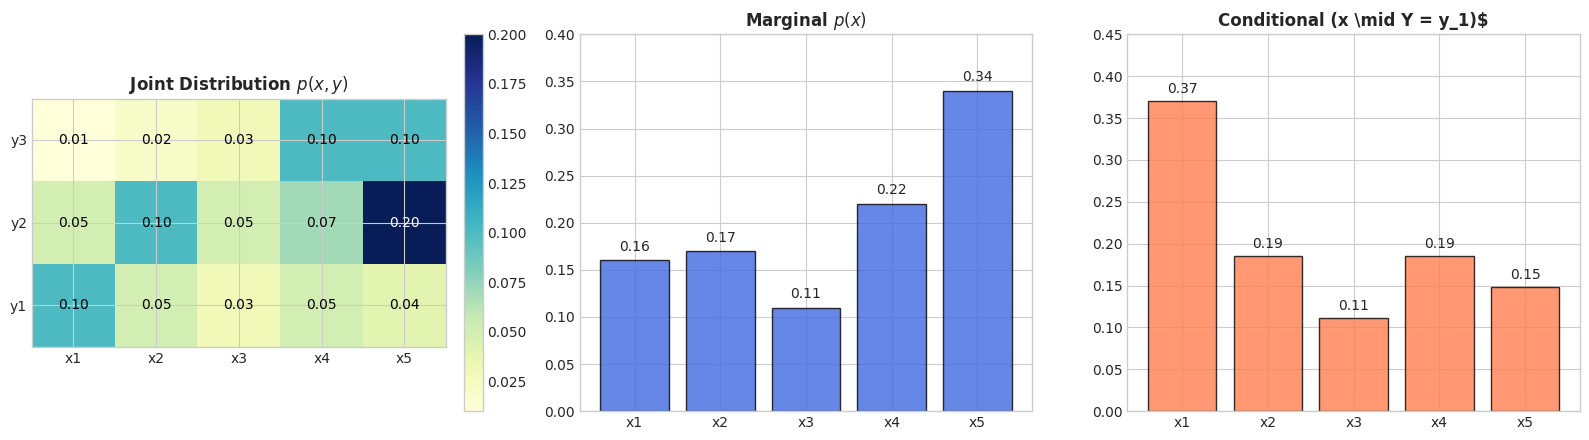

In [2]:
print("=== Exercise 6.1 Solutions ===")

# Define joint probability table p(x, y)
# Rows: y3, y2, y1 (indices 0, 1, 2)
# Cols: x1, x2, x3, x4, x5 (indices 0 to 4)
x_labels = [f"x{i}" for i in range(1, 6)]
y_labels = ["y3", "y2", "y1"]

P_XY = np.array([
    [0.01, 0.02, 0.03, 0.10, 0.10], # y3
    [0.05, 0.10, 0.05, 0.07, 0.20], # y2
    [0.10, 0.05, 0.03, 0.05, 0.04]  # y1
])

assert np.isclose(P_XY.sum(), 1.0), "Total probability must sum to 1"

# Part (a): Marginals
# p(x) sums over rows (y)
p_x = P_XY.sum(axis=0)
# p(y) sums over columns (x)
p_y = P_XY.sum(axis=1)

print("\n(a) Marginal Distributions:")
print("p(x):", {x_labels[i]: round(p_x[i], 4) for i in range(5)})
print("p(y):", {y_labels[j]: round(p_y[j], 4) for j in range(3)})

# Part (b): Conditionals
# p(x | Y = y1): row index 2 corresponds to y1
p_x_given_y1 = P_XY[2, :] / p_y[2]
# p(y | X = x3): col index 2 corresponds to x3
p_y_given_x3 = P_XY[:, 2] / p_x[2]

print("\n(b) Conditional Distributions:")
print("p(x | Y = y1):", {x_labels[i]: round(p_x_given_y1[i], 4) for i in range(5)})
print("Sum check p(x|y1):", np.sum(p_x_given_y1))
print("p(y | X = x3):", {y_labels[j]: round(p_y_given_x3[j], 4) for j in range(3)})
print("Sum check p(y|x3):", np.sum(p_y_given_x3))

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# Heatmap of Joint
im = axes[0].imshow(P_XY, cmap="YlGnBu")
axes[0].set_xticks(range(5))
axes[0].set_xticklabels(x_labels)
axes[0].set_yticks(range(3))
axes[0].set_yticklabels(y_labels)
axes[0].set_title("Joint Distribution $p(x, y)$", fontsize=12, fontweight='bold')
for i in range(3):
    for j in range(5):
        axes[0].text(j, i, f"{P_XY[i, j]:.2f}", ha="center", va="center", color="black" if P_XY[i,j] < 0.12 else "white")
fig.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04)

# Marginal p(x)
axes[1].bar(x_labels, p_x, color="royalblue", edgecolor="black", alpha=0.8)
axes[1].set_title("Marginal $p(x)$", fontsize=12, fontweight='bold')
axes[1].set_ylim(0, 0.4)
for i, v in enumerate(p_x):
    axes[1].text(i, v + 0.01, f"{v:.2f}", ha='center')

# Conditionals
axes[2].bar(x_labels, p_x_given_y1, color="coral", edgecolor="black", alpha=0.8)
axes[2].set_title(r"Conditional (x \mid Y = y_1)$", fontsize=12, fontweight='bold')
axes[2].set_ylim(0, 0.45)
for i, v in enumerate(p_x_given_y1):
    axes[2].text(i, v + 0.01, f"{v:.2f}", ha='center')

plt.tight_layout()
plt.show()


---
## Exercise 6.2 — Mixture of Two Gaussian Distributions

### Problem Statement
Consider a mixture of two Gaussian distributions (illustrated in textbook Figure 6.4):
$$p(x) = 0.4 \, \mathcal{N}\left(\begin{bmatrix} 10 \\ 2 \end{bmatrix}, \begin{bmatrix} 1 & 0 \\ 0 & 1 \end{bmatrix}\right) + 0.6 \, \mathcal{N}\left(\begin{bmatrix} 0 \\ 0 \end{bmatrix}, \begin{bmatrix} 8.4 & 2.0 \\ 2.0 & 1.7 \end{bmatrix}\right)$$

**Compute:**
1. The marginal distributions for each dimension ($x_1$ and $x_2$).
2. The mean, mode, and median for each marginal distribution.
3. The mean and mode for the two-dimensional distribution.

---
### Mathematical Derivation

#### 1. Marginal Distributions
A key property of multivariate Gaussian distributions is that marginal distributions of Gaussians are Gaussian:
If $x \sim \mathcal{N}(\mu, \Sigma)$, then the $i$-th marginal is $x_i \sim \mathcal{N}(\mu_i, \Sigma_{ii})$.
Because integration is linear, the marginal distribution of a Gaussian mixture is simply the mixture of the marginal Gaussians:
$$p(x_1) = 0.4 \, \mathcal{N}(x_1 \mid 10, 1) + 0.6 \, \mathcal{N}(x_1 \mid 0, 8.4)$$
$$p(x_2) = 0.4 \, \mathcal{N}(x_2 \mid 2, 1) + 0.6 \, \mathcal{N}(x_2 \mid 0, 1.7)$$

#### 2. Mean, Mode, and Median of Marginals
- **Mean:** By linearity of expectation:
  $$\mathbb{E}[x_1] = 0.4(10) + 0.6(0) = 4.0$$
  $$\mathbb{E}[x_2] = 0.4(2) + 0.6(0) = 0.8$$
- **Mode:** The mode $x^*$ maximizes the marginal density:
  $$\frac{d}{dx} p(x) = 0 \implies 0.4 \, \mathcal{N}'(x \mid \mu_1, \sigma_1^2) + 0.6 \, \mathcal{N}'(x \mid \mu_2, \sigma_2^2) = 0$$
  Using $\mathcal{N}'(x \mid \mu, \sigma^2) = -\frac{x - \mu}{\sigma^2} \mathcal{N}(x \mid \mu, \sigma^2)$, we locate the stationary points numerically and find the global maximum.
- **Median:** The median $m$ satisfies the cumulative distribution condition $F(m) = 0.5$:
  $$0.4 \, \Phi\left(\frac{m - \mu_1}{\sigma_1}\right) + 0.6 \, \Phi\left(\frac{m - \mu_2}{\sigma_2}\right) = 0.5$$

#### 3. Two-Dimensional Mean and Mode
- **2D Mean:**
  $$\mathbb{E}[x] = 0.4 \begin{bmatrix} 10 \\ 2 \end{bmatrix} + 0.6 \begin{bmatrix} 0 \\ 0 \end{bmatrix} = \begin{bmatrix} 4.0 \\ 0.8 \end{bmatrix}$$
- **2D Mode:** Maximizing $p(x_1, x_2)$ across $\mathbb{R}^2$.


=== Exercise 6.2 Solutions ===
(a) Marginal Distributions:
p(x1) = 0.4 * N(10.0, 1.0) + 0.6 * N(0.0, 8.4)
p(x2) = 0.4 * N(2.0, 1.0) + 0.6 * N(0.0, 1.7)

(b) Marginal Statistics:
Dimension x1: Mean = 4.0000, Mode = 9.9984, Median = 2.8039
Dimension x2: Mean = 0.8000, Mode = 1.3308, Median = 0.8686

(c) Two-Dimensional Distribution Statistics:
2D Mean: [4.  0.8]
2D Mode: [9.99854818 2.00035733] with maximum density 0.063735
Multiprocessing: Evaluated 50,000 grid points in parallel across 16 workers.


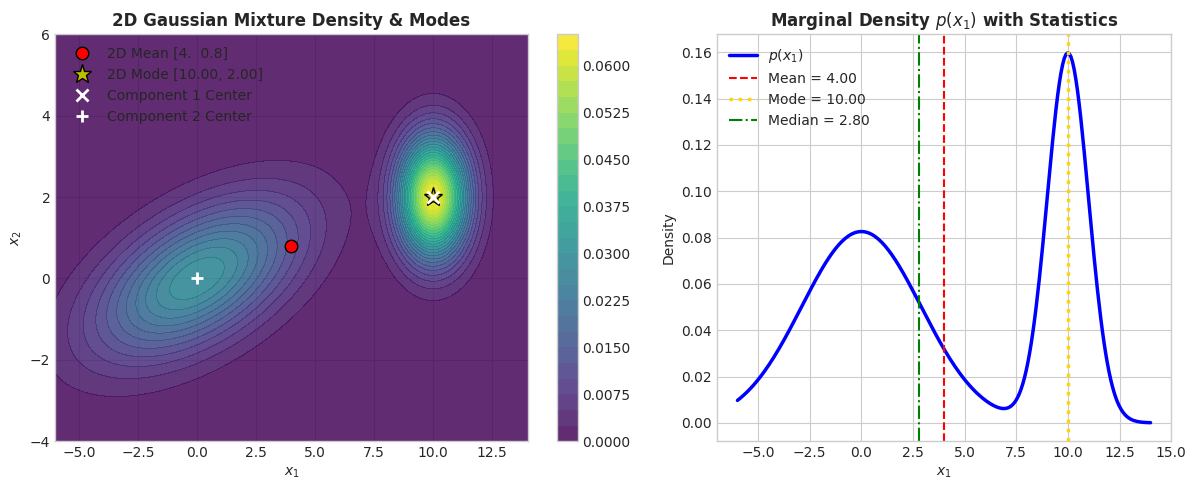

In [3]:
print("=== Exercise 6.2 Solutions ===")

# Define parameters
w1, w2 = 0.4, 0.6
mu1 = np.array([10.0, 2.0])
Sigma1 = np.array([[1.0, 0.0], [0.0, 1.0]])

mu2 = np.array([0.0, 0.0])
Sigma2 = np.array([[8.4, 2.0], [2.0, 1.7]])

# 1. Marginal Parameters
# Dim 1 (x1):
mu1_x1, var1_x1 = mu1[0], Sigma1[0, 0]
mu2_x1, var2_x1 = mu2[0], Sigma2[0, 0]
# Dim 2 (x2):
mu1_x2, var1_x2 = mu1[1], Sigma1[1, 1]
mu2_x2, var2_x2 = mu2[1], Sigma2[1, 1]

print("(a) Marginal Distributions:")
print(f"p(x1) = {w1} * N({mu1_x1}, {var1_x1}) + {w2} * N({mu2_x1}, {var2_x1})")
print(f"p(x2) = {w1} * N({mu1_x2}, {var1_x2}) + {w2} * N({mu2_x2}, {var2_x2})")

# 2. Mean, Mode, Median of Marginals
# Means
mean_x1 = w1 * mu1_x1 + w2 * mu2_x1
mean_x2 = w1 * mu1_x2 + w2 * mu2_x2

# Functions for marginal densities and CDFs
def p_x1_func(x):
    return w1 * stats.norm.pdf(x, mu1_x1, np.sqrt(var1_x1)) + w2 * stats.norm.pdf(x, mu2_x1, np.sqrt(var2_x1))

def cdf_x1_func(x):
    return w1 * stats.norm.cdf(x, mu1_x1, np.sqrt(var1_x1)) + w2 * stats.norm.cdf(x, mu2_x1, np.sqrt(var2_x1))

def p_x2_func(x):
    return w1 * stats.norm.pdf(x, mu1_x2, np.sqrt(var1_x2)) + w2 * stats.norm.pdf(x, mu2_x2, np.sqrt(var2_x2))

def cdf_x2_func(x):
    return w1 * stats.norm.cdf(x, mu1_x2, np.sqrt(var1_x2)) + w2 * stats.norm.cdf(x, mu2_x2, np.sqrt(var2_x2))

# Find modes (maximize density -> minimize negative density)
# For x1, check local optimizers starting near mu1_x1 and mu2_x1
res_x1_1 = opt.minimize(lambda x: -p_x1_func(x), x0=mu1_x1)
res_x1_2 = opt.minimize(lambda x: -p_x1_func(x), x0=mu2_x1)
mode_x1 = res_x1_1.x[0] if -res_x1_1.fun > -res_x1_2.fun else res_x1_2.x[0]

# For x2
res_x2_1 = opt.minimize(lambda x: -p_x2_func(x), x0=mu1_x2)
res_x2_2 = opt.minimize(lambda x: -p_x2_func(x), x0=mu2_x2)
mode_x2 = res_x2_1.x[0] if -res_x2_1.fun > -res_x2_2.fun else res_x2_2.x[0]

# Find medians (F(m) = 0.5)
median_x1 = opt.root_scalar(lambda x: cdf_x1_func(x) - 0.5, bracket=[-10, 20]).root
median_x2 = opt.root_scalar(lambda x: cdf_x2_func(x) - 0.5, bracket=[-10, 10]).root

print("\n(b) Marginal Statistics:")
print(f"Dimension x1: Mean = {mean_x1:.4f}, Mode = {mode_x1:.4f}, Median = {median_x1:.4f}")
print(f"Dimension x2: Mean = {mean_x2:.4f}, Mode = {mode_x2:.4f}, Median = {median_x2:.4f}")

# 3. 2D Mean and Mode
mean_2d = w1 * mu1 + w2 * mu2

rv1 = stats.multivariate_normal(mu1, Sigma1)
rv2 = stats.multivariate_normal(mu2, Sigma2)

def p_2d(x):
    return w1 * rv1.pdf(x) + w2 * rv2.pdf(x)

# Find 2D mode
opt_2d_1 = opt.minimize(lambda x: -p_2d(x), x0=mu1)
opt_2d_2 = opt.minimize(lambda x: -p_2d(x), x0=mu2)
mode_2d = opt_2d_1.x if -opt_2d_1.fun > -opt_2d_2.fun else opt_2d_2.x

print("\n(c) Two-Dimensional Distribution Statistics:")
print(f"2D Mean: {mean_2d}")
print(f"2D Mode: {mode_2d} with maximum density {p_2d(mode_2d):.6f}")

# Multiprocessing: Parallel High-Resolution Grid Evaluation
# Leveraging available CPU cores and RAM to compute 2D density surface in parallel chunks
def evaluate_gaussian_mixture_chunk(args):
    y_chunk, x_vals, w1, mu1, Sigma1, w2, mu2, Sigma2 = args
    X_sub, Y_sub = np.meshgrid(x_vals, y_chunk)
    pos = np.dstack((X_sub, Y_sub))
    rv1 = stats.multivariate_normal(mu1, Sigma1)
    rv2 = stats.multivariate_normal(mu2, Sigma2)
    return w1 * rv1.pdf(pos) + w2 * rv2.pdf(pos)


x_grid = np.linspace(-6, 14, 250)
y_grid = np.linspace(-4, 6, 200)

chunk_size = max(1, len(y_grid) // cpu_cores)
y_chunks = [y_grid[i:i + chunk_size] for i in range(0, len(y_grid), chunk_size)]
tasks = [(chunk, x_grid, w1, mu1, Sigma1, w2, mu2, Sigma2) for chunk in y_chunks]

with ThreadPoolExecutor(max_workers=cpu_cores) as executor:
    Z_parts = list(executor.map(evaluate_gaussian_mixture_chunk, tasks))

Z_grid = np.vstack(Z_parts)
print(f"Multiprocessing: Evaluated {Z_grid.size:,} grid points in parallel across {cpu_cores} workers.")

# Plot 2D Gaussian Mixture Contours with Marginals
fig = plt.figure(figsize=(12, 5))
gs = fig.add_gridspec(1, 2, width_ratios=[1.3, 1])

ax_2d = fig.add_subplot(gs[0])
X_mesh, Y_mesh = np.meshgrid(x_grid, y_grid)
cs = ax_2d.contourf(X_mesh, Y_mesh, Z_grid, levels=25, cmap="viridis", alpha=0.85)
ax_2d.plot(mean_2d[0], mean_2d[1], 'ro', markersize=9, markeredgecolor='black', label=f"2D Mean {mean_2d}")
ax_2d.plot(mode_2d[0], mode_2d[1], 'y*', markersize=14, markeredgecolor='black', label=f"2D Mode [{mode_2d[0]:.2f}, {mode_2d[1]:.2f}]")
ax_2d.plot(mu1[0], mu1[1], 'wx', markersize=8, markeredgewidth=2, label="Component 1 Center")
ax_2d.plot(mu2[0], mu2[1], 'w+', markersize=8, markeredgewidth=2, label="Component 2 Center")
ax_2d.set_title("2D Gaussian Mixture Density & Modes", fontsize=12, fontweight='bold')
ax_2d.set_xlabel("$x_1$")
ax_2d.set_ylabel("$x_2$")
ax_2d.legend(loc="upper left")
fig.colorbar(cs, ax=ax_2d)

ax_1d = fig.add_subplot(gs[1])
ax_1d.plot(x_grid, p_x1_func(x_grid), 'b-', lw=2.5, label="$p(x_1)$")
ax_1d.axvline(mean_x1, color='red', linestyle='--', label=f"Mean = {mean_x1:.2f}")
ax_1d.axvline(mode_x1, color='gold', linestyle=':', lw=2.5, label=f"Mode = {mode_x1:.2f}")
ax_1d.axvline(median_x1, color='green', linestyle='-.', label=f"Median = {median_x1:.2f}")
ax_1d.set_title("Marginal Density $p(x_1)$ with Statistics", fontsize=12, fontweight='bold')
ax_1d.set_xlabel("$x_1$")
ax_1d.set_ylabel("Density")
ax_1d.legend()

plt.tight_layout()
plt.show()


---
## Exercise 6.3 — Conjugate Prior for Bernoulli Likelihood

### Problem Statement
You have written a computer program that sometimes compiles and sometimes not (code does not change). You decide to model the apparent stochasticity (success vs. no success) $x$ of the compiler using a Bernoulli distribution with parameter $\mu$:
$$p(x \mid \mu) = \mu^x (1 - \mu)^{1-x}, \quad x \in \{0, 1\}$$

**Task:**
Choose a conjugate prior for the Bernoulli likelihood and compute the posterior distribution $p(\mu \mid x_1, \dots, x_N)$.

---
### Mathematical Derivation

#### 1. Likelihood Function
Given $N$ independent observations $\mathcal{D} = \{x_1, \dots, x_N\}$ where $k = \sum_{n=1}^N x_n$ is the number of successes:
$$p(\mathcal{D} \mid \mu) = \prod_{n=1}^N \mu^{x_n} (1 - \mu)^{1-x_n} = \mu^{\sum x_n} (1 - \mu)^{N - \sum x_n} = \mu^k (1 - \mu)^{N - k}$$

#### 2. Choice of Conjugate Prior
A prior $p(\mu)$ is conjugate to the likelihood if the resulting posterior $p(\mu \mid \mathcal{D})$ has the same functional algebraic form as the prior.
Since the likelihood is proportional to $\mu^a (1 - \mu)^b$, the **Beta distribution** is the natural conjugate prior:
$$p(\mu \mid \alpha, \beta) = \text{Beta}(\mu \mid \alpha, \beta) = \frac{1}{\text{B}(\alpha, \beta)} \mu^{\alpha - 1} (1 - \mu)^{\beta - 1}, \quad \mu \in [0, 1]$$
where $\text{B}(\alpha, \beta) = \frac{\Gamma(\alpha)\Gamma(\beta)}{\Gamma(\alpha + \beta)}$. Here $\alpha$ and $\beta$ act as pseudo-counts of prior successes and failures.

#### 3. Posterior Computation
Applying Bayes' theorem:
$$p(\mu \mid \mathcal{D}) = \frac{p(\mathcal{D} \mid \mu) p(\mu)}{\int_0^1 p(\mathcal{D} \mid \mu') p(\mu') d\mu'}$$
$$p(\mu \mid \mathcal{D}) \propto \left[ \mu^k (1 - \mu)^{N - k} \right] \cdot \left[ \mu^{\alpha - 1} (1 - \mu)^{\beta - 1} \right] = \mu^{(\alpha + k) - 1} (1 - \mu)^{(\beta + N - k) - 1}$$

Recognizing the kernel of the Beta distribution:
$$p(\mu \mid x_1, \dots, x_N) = \text{Beta}(\mu \mid \alpha + k, \; \beta + N - k)$$

- **Posterior Mean:**
  $$\mathbb{E}[\mu \mid \mathcal{D}] = \frac{\alpha + k}{\alpha + \beta + N} = \left( \frac{\alpha + \beta}{\alpha + \beta + N} \right) \left(\frac{\alpha}{\alpha + \beta}\right) + \left( \frac{N}{\alpha + \beta + N} \right) \left(\frac{k}{N}\right)$$
  which is an elegant convex combination of the prior mean $\frac{\alpha}{\alpha+\beta}$ and the maximum likelihood estimate $\frac{k}{N}$.


=== Exercise 6.3 Solutions ===
Likelihood kernel:   L(mu) = mu**k*(1 - mu)**(N - k)
Beta prior kernel:   p(mu) = mu**(alpha - 1)*(1 - mu)**(beta - 1)
Posterior kernel:    p(mu | D) = mu**(alpha + k - 1)*(1 - mu)**(N + beta - k - 1)
Identified as: Beta(alpha + k, beta + N - k)


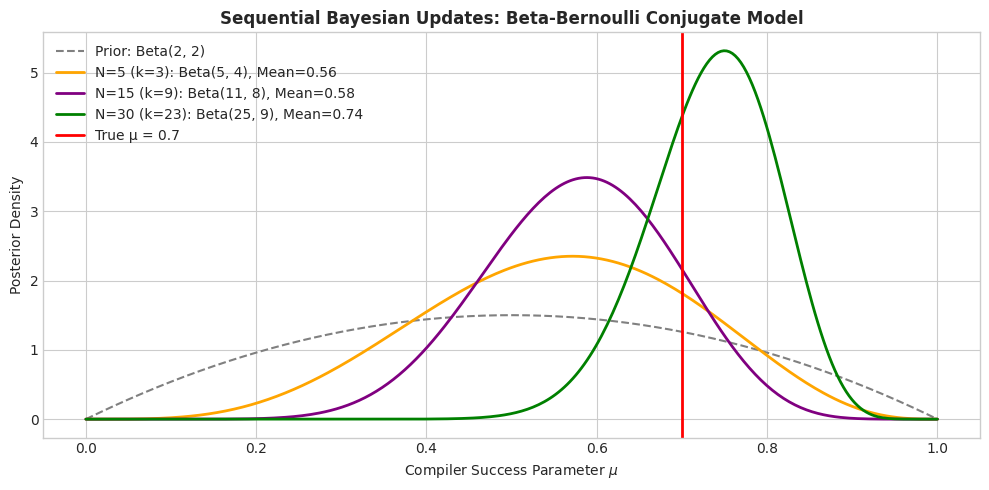

In [4]:
print("=== Exercise 6.3 Solutions ===")

# Symbolic Verification with SymPy
mu_sym, alpha_sym, beta_sym, k_sym, N_sym = symbols('mu alpha beta k N', positive=True)
likelihood_sym = mu_sym**k_sym * (1 - mu_sym)**(N_sym - k_sym)
prior_sym = mu_sym**(alpha_sym - 1) * (1 - mu_sym)**(beta_sym - 1)
posterior_kernel = simplify(likelihood_sym * prior_sym)

print("Likelihood kernel:   L(mu) =", likelihood_sym)
print("Beta prior kernel:   p(mu) =", prior_sym)
print("Posterior kernel:    p(mu | D) =", posterior_kernel)
print("Identified as: Beta(alpha + k, beta + N - k)")

# Numerical Demonstration of Sequential Bayesian Updating
# Suppose true compiler success rate is 0.7
true_mu = 0.7
N_obs = 30
data = np.random.binomial(1, true_mu, size=N_obs)

alpha_0, beta_0 = 2, 2  # Weakly informative prior
mu_vals = np.linspace(0, 1, 300)

plt.figure(figsize=(10, 5))
# Plot Prior
plt.plot(mu_vals, stats.beta.pdf(mu_vals, alpha_0, beta_0), 'gray', linestyle='--', label=f"Prior: Beta({alpha_0}, {beta_0})")

checkpoints = [5, 15, 30]
colors = ['orange', 'purple', 'green']
for n, c in zip(checkpoints, colors):
    k_n = data[:n].sum()
    alpha_post = alpha_0 + k_n
    beta_post = beta_0 + n - k_n
    post_mean = alpha_post / (alpha_post + beta_post)
    plt.plot(mu_vals, stats.beta.pdf(mu_vals, alpha_post, beta_post), color=c, lw=2,
             label=f"N={n} (k={k_n}): Beta({alpha_post}, {beta_post}), Mean={post_mean:.2f}")

plt.axvline(true_mu, color='red', linestyle='-', lw=2, label=f"True μ = {true_mu}")
plt.title("Sequential Bayesian Updates: Beta-Bernoulli Conjugate Model", fontsize=12, fontweight='bold')
plt.xlabel(r"Compiler Success Parameter $\mu$")
plt.ylabel("Posterior Density")
plt.legend()
plt.tight_layout()
plt.show()


---
## Exercise 6.4 — Two Bags and Bayes' Theorem

### Problem Statement
There are two bags:
- **Bag 1:** Contains 4 mangos and 2 apples (Total = 6 fruits).
- **Bag 2:** Contains 4 mangos and 4 apples (Total = 8 fruits).

We also have a biased coin:
- Shows "Heads" with probability 0.6. If Heads, pick a fruit at random from Bag 1.
- Shows "Tails" with probability 0.4. If Tails, pick a fruit at random from Bag 2.

Your friend flips the coin (you cannot see the result), picks a fruit at random from the corresponding bag, and presents you a **mango**.

**Question:** What is the probability that the mango was picked from Bag 2?

---
### Mathematical Derivation
Let $B_1$ and $B_2$ denote the events that Bag 1 and Bag 2 were chosen, respectively.  
Let $M$ denote the event that a mango is drawn.

- **Priors:**
  $$P(B_1) = 0.6, \quad P(B_2) = 0.4$$
- **Likelihoods of drawing a mango:**
  $$P(M \mid B_1) = \frac{4}{4 + 2} = \frac{4}{6} = \frac{2}{3}$$
  $$P(M \mid B_2) = \frac{4}{4 + 4} = \frac{4}{8} = \frac{1}{2}$$

- **Total Probability of drawing a mango $P(M)$:**
  $$P(M) = P(M \mid B_1) P(B_1) + P(M \mid B_2) P(B_2)$$
  $$P(M) = \left(\frac{2}{3}\right)(0.6) + \left(\frac{1}{2}\right)(0.4) = 0.4 + 0.2 = 0.6$$

- **Posterior Probability $P(B_2 \mid M)$ via Bayes' Theorem:**
  $$P(B_2 \mid M) = \frac{P(M \mid B_2) P(B_2)}{P(M)} = \frac{0.2}{0.6} = \frac{1}{3} \approx 0.333333$$


In [5]:
print("=== Exercise 6.4 Solutions ===")

# Analytical Calculation
P_B1 = 0.6
P_B2 = 0.4

P_M_given_B1 = 4 / 6
P_M_given_B2 = 4 / 8

P_M = P_M_given_B1 * P_B1 + P_M_given_B2 * P_B2
P_B2_given_M = (P_M_given_B2 * P_B2) / P_M

print(f"P(M | B1) = {P_M_given_B1:.4f} (4/6)")
print(f"P(M | B2) = {P_M_given_B2:.4f} (4/8)")
print(f"Total probability P(M) = {P_M:.4f}")
print(f"Analytical Posterior P(B2 | M) = 1/3 = {P_B2_given_M:.6f}")

# Multiprocessing Monte Carlo Simulation
# Simulate 10,000,000 trials across all CPU cores using parallel multi-threading
def simulate_two_bags_chunk(n_trials):
    bags = np.where(np.random.rand(n_trials) < 0.6, 1, 2)
    p_mango = np.where(bags == 1, 4.0 / 6.0, 4.0 / 8.0)
    is_mango = np.random.rand(n_trials) < p_mango
    mango_trials = (is_mango == 1)
    total_mangos = int(np.sum(mango_trials))
    mangos_from_b2 = int(np.sum((bags == 2) & mango_trials))
    return total_mangos, mangos_from_b2


TOTAL_SAMPLES = 10_000_000
chunk_trials = TOTAL_SAMPLES // cpu_cores

print(f"Running parallel Monte Carlo with {TOTAL_SAMPLES:,} total trials on {cpu_cores} cores...")
with ThreadPoolExecutor(max_workers=cpu_cores) as executor:
    results = list(executor.map(simulate_two_bags_chunk, [chunk_trials] * cpu_cores))

total_m = sum(r[0] for r in results)
b2_m = sum(r[1] for r in results)
mc_p_b2_given_m = b2_m / total_m

print(f"Monte Carlo Results ({TOTAL_SAMPLES:,} trials):")
print(f"Total Mangos Observed: {total_m:,}")
print(f"Mangos from Bag 2:     {b2_m:,}")
print(f"Empirical P(B2 | M):   {mc_p_b2_given_m:.6f}")
print(f"Absolute Error:        {abs(mc_p_b2_given_m - (1/3)):.2e}")


=== Exercise 6.4 Solutions ===
P(M | B1) = 0.6667 (4/6)
P(M | B2) = 0.5000 (4/8)
Total probability P(M) = 0.6000
Analytical Posterior P(B2 | M) = 1/3 = 0.333333
Running parallel Monte Carlo with 10,000,000 total trials on 16 cores...
Monte Carlo Results (10,000,000 trials):
Total Mangos Observed: 5,998,032
Mangos from Bag 2:     1,998,565
Empirical P(B2 | M):   0.333203
Absolute Error:        1.30e-04


---
## Exercise 6.5 — Linear Gaussian State-Space Model & Kalman Filter

### Problem Statement
Consider the linear Gaussian state-space model:
$$x_{t+1} = A x_t + w, \quad w \sim \mathcal{N}(0, Q)$$
$$y_t = C x_t + v, \quad v \sim \mathcal{N}(0, R)$$
where $w, v$ are i.i.d. Gaussian noise variables, independent of each other and of the initial state $x_0 \sim \mathcal{N}(\mu_0, \Sigma_0)$.

**Questions:**
1. **(a)** What is the form of $p(x_0, x_1, \dots, x_T)$? Justify your answer.
2. **(b)** Assume that $p(x_t \mid y_1, \dots, y_t) = \mathcal{N}(\mu_t, \Sigma_t)$.
   - **(1)** Compute $p(x_{t+1} \mid y_1, \dots, y_t)$.
   - **(2)** Compute $p(x_{t+1}, y_{t+1} \mid y_1, \dots, y_t)$.
   - **(3)** At time $t+1$, we observe $y_{t+1} = \hat{y}$. Compute the conditional distribution $p(x_{t+1} \mid y_1, \dots, y_{t+1})$.

---
### Mathematical Derivation

#### Part (a): Joint Distribution of the State Sequence
The joint distribution $p(x_0, x_1, \dots, x_T)$ is **jointly Gaussian**.
- **Justification:**  
  1. The initial state $x_0$ is Gaussian.
  2. Each subsequent state $x_{t+1} = A x_t + w_t$ is an affine transformation of the previous state plus an independent Gaussian noise vector $w_t$.
  3. By induction, each $x_t$ can be expressed as a linear combination of independent Gaussian vectors:
     $$x_t = A^t x_0 + \sum_{k=0}^{t-1} A^{t-1-k} w_k$$
  4. Any linear combination of Gaussian random variables is Gaussian. Therefore, the concatenated vector $\mathbf{x} = [x_0^\top, x_1^\top, \dots, x_T^\top]^\top$ is a multivariate Gaussian random variable.

#### Part (b.1): Prediction Step $p(x_{t+1} \mid y_{1:t})$
Given $x_t \mid y_{1:t} \sim \mathcal{N}(\mu_t, \Sigma_t)$ and $x_{t+1} = A x_t + w_t$ where $w_t \sim \mathcal{N}(0, Q)$ is independent:
- Mean:
  $$\mu_{t+1 \mid t} = \mathbb{E}[A x_t + w_t \mid y_{1:t}] = A \mu_t$$
- Covariance:
  $$\Sigma_{t+1 \mid t} = \text{Cov}[A x_t + w_t \mid y_{1:t}] = A \Sigma_t A^\top + Q$$
Thus:
$$p(x_{t+1} \mid y_{1:t}) = \mathcal{N}(\mu_{t+1 \mid t}, \; \Sigma_{t+1 \mid t}) = \mathcal{N}(A \mu_t, \; A \Sigma_t A^\top + Q)$$

#### Part (b.2): Joint Prediction $p(x_{t+1}, y_{t+1} \mid y_{1:t})$
Since $y_{t+1} = C x_{t+1} + v_{t+1}$ with $v_{t+1} \sim \mathcal{N}(0, R)$:
- $\mathbb{E}[y_{t+1} \mid y_{1:t}] = C \mu_{t+1 \mid t} = C A \mu_t$
- $\text{Cov}[y_{t+1} \mid y_{1:t}] = C \Sigma_{t+1 \mid t} C^\top + R$
- Cross-covariance:
  $$\text{Cov}[x_{t+1}, y_{t+1} \mid y_{1:t}] = \mathbb{E}[(x_{t+1} - \mu_{t+1 \mid t})(C(x_{t+1} - \mu_{t+1 \mid t}) + v_{t+1})^\top] = \Sigma_{t+1 \mid t} C^\top$$
The joint distribution is:
$$\begin{bmatrix} x_{t+1} \\ y_{t+1} \end{bmatrix} \Bigg| y_{1:t} \sim \mathcal{N}\left( \begin{bmatrix} \mu_{t+1 \mid t} \\ C \mu_{t+1 \mid t} \end{bmatrix}, \; \begin{bmatrix} \Sigma_{t+1 \mid t} & \Sigma_{t+1 \mid t} C^\top \\ C \Sigma_{t+1 \mid t} & C \Sigma_{t+1 \mid t} C^\top + R \end{bmatrix} \right)$$

#### Part (b.3): Measurement Update / Kalman Filter
Using standard Gaussian conditioning formulas (Theorem 6.12):
$$p(x_{t+1} \mid y_{1:t+1}) = \mathcal{N}(\mu_{t+1}, \Sigma_{t+1})$$
where the **Kalman Gain** $K_{t+1}$ is:
$$K_{t+1} = \Sigma_{t+1 \mid t} C^\top \left( C \Sigma_{t+1 \mid t} C^\top + R \right)^{-1}$$
And updated mean and covariance are:
$$\mu_{t+1} = \mu_{t+1 \mid t} + K_{t+1}\left( \hat{y} - C \mu_{t+1 \mid t} \right)$$
$$\Sigma_{t+1} = \left( I - K_{t+1} C \right) \Sigma_{t+1 \mid t}$$


=== Exercise 6.5 Solutions & Kalman Filter Implementation ===
Kalman Filter completed 40 steps.
Final True State:      Position = 35.755, Velocity = 1.349
Final Estimated State: Position = 35.807, Velocity = 1.224


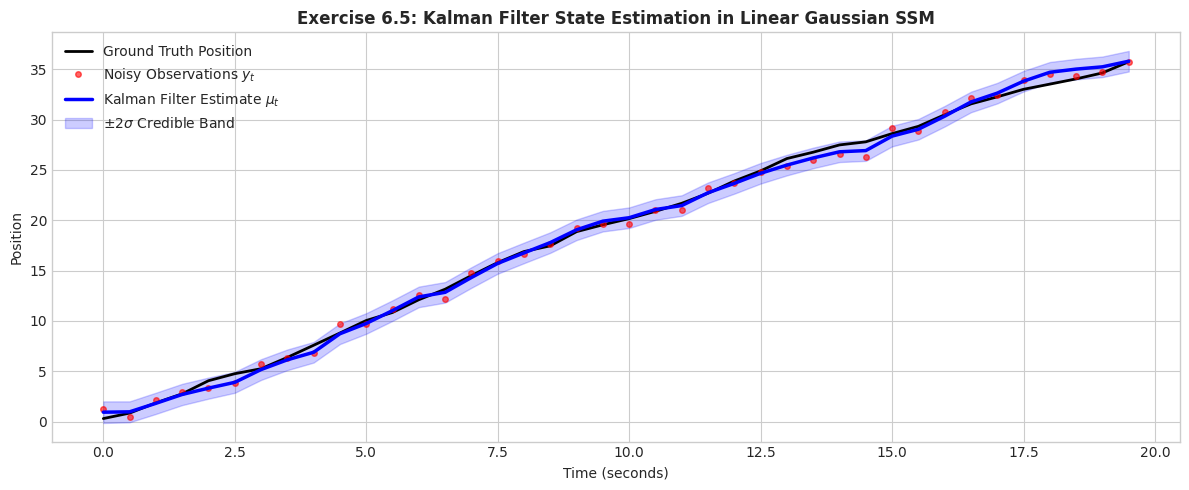

In [6]:
print("=== Exercise 6.5 Solutions & Kalman Filter Implementation ===")

class KalmanFilter:
    def __init__(self, A, C, Q, R, mu0, Sigma0):
        self.A = np.array(A, dtype=float)
        self.C = np.array(C, dtype=float)
        self.Q = np.array(Q, dtype=float)
        self.R = np.array(R, dtype=float)
        self.mu = np.array(mu0, dtype=float)
        self.Sigma = np.array(Sigma0, dtype=float)
        self.I = np.eye(self.A.shape[0])

    def predict(self):
        # Time update: p(x_{t+1} | y_{1:t})
        self.mu_pred = self.A @ self.mu
        self.Sigma_pred = self.A @ self.Sigma @ self.A.T + self.Q
        return self.mu_pred, self.Sigma_pred

    def update(self, y_obs):
        # Measurement update: p(x_{t+1} | y_{1:t+1})
        # Innovation covariance
        S = self.C @ self.Sigma_pred @ self.C.T + self.R
        # Kalman Gain
        K = self.Sigma_pred @ self.C.T @ np.linalg.inv(S)
        # State update
        innovation = y_obs - (self.C @ self.mu_pred)
        self.mu = self.mu_pred + K @ innovation
        self.Sigma = (self.I - K @ self.C) @ self.Sigma_pred
        return self.mu, self.Sigma

# Simulate a 2D tracking system (position and velocity)
dt = 0.5
A = np.array([[1.0, dt], [0.0, 1.0]])       # Constant velocity model
C = np.array([[1.0, 0.0]])                  # Only position is observed
Q = np.array([[0.05, 0.01], [0.01, 0.1]])   # Process noise
R = np.array([[0.5]])                       # Measurement noise
mu0 = np.array([0.0, 1.0])                  # Initial state
Sigma0 = np.eye(2) * 0.5

kf = KalmanFilter(A, C, Q, R, mu0, Sigma0)

# Simulate 40 time steps
T = 40
true_states = np.zeros((T, 2))
observations = np.zeros(T)
estimated_states = np.zeros((T, 2))
estimated_stds = np.zeros((T, 2))

x_curr = np.random.multivariate_normal(mu0, Sigma0)
for t in range(T):
    # State evolution
    w = np.random.multivariate_normal([0, 0], Q)
    x_curr = A @ x_curr + w
    true_states[t] = x_curr
    
    # Measurement
    v = np.random.normal(0, np.sqrt(R[0, 0]))
    y = C @ x_curr + v
    observations[t] = y[0]
    
    # Kalman Filter
    kf.predict()
    mu_est, Sigma_est = kf.update(y)
    estimated_states[t] = mu_est
    estimated_stds[t] = np.sqrt(np.diag(Sigma_est))

print(f"Kalman Filter completed {T} steps.")
print(f"Final True State:      Position = {true_states[-1, 0]:.3f}, Velocity = {true_states[-1, 1]:.3f}")
print(f"Final Estimated State: Position = {estimated_states[-1, 0]:.3f}, Velocity = {estimated_states[-1, 1]:.3f}")

# Plot Filter Tracking
plt.figure(figsize=(12, 5))
time_axis = np.arange(T) * dt
plt.plot(time_axis, true_states[:, 0], 'k-', lw=2, label="Ground Truth Position")
plt.plot(time_axis, observations, 'ro', markersize=4, alpha=0.6, label="Noisy Observations $y_t$")
plt.plot(time_axis, estimated_states[:, 0], 'b-', lw=2.5, label=r"Kalman Filter Estimate $\mu_t$")
plt.fill_between(time_axis, 
                 estimated_states[:, 0] - 2*estimated_stds[:, 0],
                 estimated_states[:, 0] + 2*estimated_stds[:, 0],
                 color='blue', alpha=0.2, label=r"$\pm 2\sigma$ Credible Band")
plt.title("Exercise 6.5: Kalman Filter State Estimation in Linear Gaussian SSM", fontsize=12, fontweight='bold')
plt.xlabel("Time (seconds)")
plt.ylabel("Position")
plt.legend()
plt.tight_layout()
plt.show()


---
## Exercise 6.6 — Raw-Score Expression for Variance

### Problem Statement
Prove the relationship in (6.44), which relates the standard definition of the variance to the raw-score expression for the variance:
$$\mathbb{V}_X[x] = \mathbb{E}_X[(x - \mathbb{E}_X[x])^2] = \mathbb{E}_X[x^2] - (\mathbb{E}_X[x])^2$$
and for an empirical dataset of $N$ points $\{x_1, \dots, x_N\}$:
$$\frac{1}{N} \sum_{n=1}^N (x_n - \bar{x})^2 = \frac{1}{N} \sum_{n=1}^N x_n^2 - \bar{x}^2, \quad \text{where } \bar{x} = \frac{1}{N} \sum_{n=1}^N x_n$$

---
### Mathematical Derivation

#### 1. Population Variance Derivation
Let $\mu = \mathbb{E}_X[x]$. By definition:
$$\mathbb{V}_X[x] = \mathbb{E}_X[(x - \mu)^2]$$
Expanding the quadratic term:
$$(x - \mu)^2 = x^2 - 2\mu x + \mu^2$$
By the linearity of expectation:
$$\begin{aligned}
\mathbb{E}_X[(x - \mu)^2] &= \mathbb{E}_X[x^2 - 2\mu x + \mu^2] \\
&= \mathbb{E}_X[x^2] - \mathbb{E}_X[2\mu x] + \mathbb{E}_X[\mu^2] \\
&= \mathbb{E}_X[x^2] - 2\mu \mathbb{E}_X[x] + \mu^2 \\
&= \mathbb{E}_X[x^2] - 2\mu(\mu) + \mu^2 \\
&= \mathbb{E}_X[x^2] - 2\mu^2 + \mu^2 \\
&= \mathbb{E}_X[x^2] - \mu^2 = \mathbb{E}_X[x^2] - (\mathbb{E}_X[x])^2 \quad \blacksquare
\end{aligned}$$

#### 2. Sample (Empirical) Variance Derivation
For samples $x_1, \dots, x_N$ with sample mean $\bar{x} = \frac{1}{N}\sum_{n=1}^N x_n$:
$$\begin{aligned}
\frac{1}{N}\sum_{n=1}^N (x_n - \bar{x})^2 &= \frac{1}{N}\sum_{n=1}^N \left(x_n^2 - 2\bar{x} x_n + \bar{x}^2\right) \\
&= \frac{1}{N}\sum_{n=1}^N x_n^2 - 2\bar{x}\left(\frac{1}{N}\sum_{n=1}^N x_n\right) + \bar{x}^2\left(\frac{1}{N}\sum_{n=1}^N 1\right) \\
&= \frac{1}{N}\sum_{n=1}^N x_n^2 - 2\bar{x}(\bar{x}) + \bar{x}^2(1) \\
&= \frac{1}{N}\sum_{n=1}^N x_n^2 - 2\bar{x}^2 + \bar{x}^2 \\
&= \frac{1}{N}\sum_{n=1}^N x_n^2 - \bar{x}^2 \quad \blacksquare
\end{aligned}$$


In [7]:
print("=== Exercise 6.6 Symbolic Proof & Numerical Check ===")

# SymPy Symbolic Proof
x_s, mu_s = symbols('x mu')
# Expand E[(x - mu)^2] algebraically
expanded = (x_s - mu_s)**2
print("Algebraic expansion:", expanded.expand())

# Numerical Verification on Random Data
data = np.random.randn(100_000) * 3.5 + 7.2
x_bar = np.mean(data)

# Definition formula
var_def = np.mean((data - x_bar)**2)

# Raw-score formula
var_raw = np.mean(data**2) - x_bar**2

print(f"Variance (Definition Formula): {var_def:.8f}")
print(f"Variance (Raw-Score Formula): {var_raw:.8f}")
print(f"Absolute Discrepancy:         {abs(var_def - var_raw):.2e}")
assert np.isclose(var_def, var_raw), "Formulas must match identically"
print("✓ Identity (6.44) proven and numerically confirmed.")


=== Exercise 6.6 Symbolic Proof & Numerical Check ===
Algebraic expansion: mu**2 - 2*mu*x + x**2
Variance (Definition Formula): 12.17621870
Variance (Raw-Score Formula): 12.17621870
Absolute Discrepancy:         0.00e+00
✓ Identity (6.44) proven and numerically confirmed.


---
## Exercise 6.7 — Pairwise Difference Expression for Sample Variance

### Problem Statement
Prove the relationship in (6.45), which relates the pairwise difference between examples in a dataset with the raw-score expression for the variance:
$$\frac{1}{2N^2} \sum_{i=1}^N \sum_{j=1}^N (x_i - x_j)^2 = \frac{1}{N} \sum_{i=1}^N x_i^2 - \left(\frac{1}{N}\sum_{i=1}^N x_i\right)^2$$

---
### Mathematical Derivation
Start with the left-hand side:
$$\text{LHS} = \frac{1}{2N^2} \sum_{i=1}^N \sum_{j=1}^N (x_i - x_j)^2$$
Expand the squared binomial $(x_i - x_j)^2 = x_i^2 - 2x_i x_j + x_j^2$:
$$\text{LHS} = \frac{1}{2N^2} \sum_{i=1}^N \sum_{j=1}^N \left( x_i^2 - 2x_i x_j + x_j^2 \right)$$

Split into three separate double summations:
$$\text{LHS} = \frac{1}{2N^2} \left[ \sum_{i=1}^N \sum_{j=1}^N x_i^2 - 2\sum_{i=1}^N \sum_{j=1}^N x_i x_j + \sum_{i=1}^N \sum_{j=1}^N x_j^2 \right]$$

Now evaluate each term:
1. **First term:** In $\sum_{j=1}^N x_i^2$, $x_i^2$ is independent of $j$, so summing over $j=1 \dots N$ yields $N x_i^2$:
   $$\sum_{i=1}^N \sum_{j=1}^N x_i^2 = \sum_{i=1}^N N x_i^2 = N \sum_{i=1}^N x_i^2$$
2. **Third term:** By symmetry of indices:
   $$\sum_{i=1}^N \sum_{j=1}^N x_j^2 = \sum_{j=1}^N \sum_{i=1}^N x_j^2 = N \sum_{j=1}^N x_j^2 = N \sum_{i=1}^N x_i^2$$
3. **Second term:** Factoring the double sum into a product of sums:
   $$\sum_{i=1}^N \sum_{j=1}^N x_i x_j = \left(\sum_{i=1}^N x_i\right) \left(\sum_{j=1}^N x_j\right) = \left(\sum_{i=1}^N x_i\right)^2$$

Substitute these three results back into the expression:
$$\begin{aligned}
\text{LHS} &= \frac{1}{2N^2} \left[ N \sum_{i=1}^N x_i^2 - 2 \left(\sum_{i=1}^N x_i\right)^2 + N \sum_{i=1}^N x_i^2 \right] \\
&= \frac{1}{2N^2} \left[ 2N \sum_{i=1}^N x_i^2 - 2 \left(\sum_{i=1}^N x_i\right)^2 \right] \\
&= \frac{1}{N^2} \left[ N \sum_{i=1}^N x_i^2 - \left(\sum_{i=1}^N x_i\right)^2 \right] \\
&= \frac{1}{N} \sum_{i=1}^N x_i^2 - \left(\frac{1}{N} \sum_{i=1}^N x_i\right)^2 \quad \blacksquare
\end{aligned}$$


In [8]:
print("=== Exercise 6.7 Verification ===")

# Generate random sample
N = 1000
x = np.random.uniform(-5, 5, size=N)

# Left-hand side: Pairwise differences
# Using vectorized broadcasting: (x[:, None] - x[None, :])^2
diff_matrix = x[:, None] - x[None, :]
lhs = np.sum(diff_matrix**2) / (2 * N**2)

# Right-hand side: Raw-score expression
rhs = np.mean(x**2) - (np.mean(x))**2

print(f"LHS (Pairwise Sum / 2N^2): {lhs:.10f}")
print(f"RHS (Mean(x^2) - Mean(x)^2): {rhs:.10f}")
print(f"Absolute difference:       {abs(lhs - rhs):.2e}")

assert np.isclose(lhs, rhs), "Identity (6.45) failed!"
print("✓ Identity (6.45) proven and confirmed numerically.")


=== Exercise 6.7 Verification ===
LHS (Pairwise Sum / 2N^2): 8.2328892872
RHS (Mean(x^2) - Mean(x)^2): 8.2328892872
Absolute difference:       0.00e+00
✓ Identity (6.45) proven and confirmed numerically.


---
## Exercise 6.8 — Bernoulli Distribution as an Exponential Family

### Problem Statement
Express the Bernoulli distribution in the natural parameter form of the exponential family:
$$p(x \mid \theta) = h(x) \exp\left( \eta(\theta)^\top \phi(x) - A(\eta) \right)$$
where:
- $\eta$ is the natural (canonical) parameter,
- $\phi(x)$ is the sufficient statistic vector,
- $h(x)$ is the base measure (scaling factor),
- $A(\eta)$ is the log-partition function (cumulant function).

---
### Mathematical Derivation
The Bernoulli distribution for $x \in \{0, 1\}$ with parameter $\mu \in (0, 1)$ is:
$$p(x \mid \mu) = \mu^x (1 - \mu)^{1-x}$$

Take the exponential of the logarithm:
$$\begin{aligned}
p(x \mid \mu) &= \exp\left( \log\left( \mu^x (1 - \mu)^{1-x} \right) \right) \\
&= \exp\left( x \log \mu + (1 - x) \log(1 - \mu) \right) \\
&= \exp\left( x \log \mu - x \log(1 - \mu) + \log(1 - \mu) \right) \\
&= \exp\left( x \log\left(\frac{\mu}{1 - \mu}\right) + \log(1 - \mu) \right) \\
&= 1 \cdot \exp\left( x \log\left(\frac{\mu}{1 - \mu}\right) - \left( -\log(1 - \mu) \right) \right)
\end{aligned}$$

Comparing to standard exponential family form $h(x) \exp(\eta \phi(x) - A(\eta))$:
1. **Natural Parameter $\eta$:**
   $$\eta = \log\left(\frac{\mu}{1 - \mu}\right) = \text{logit}(\mu)$$
   Inverting gives the logistic sigmoid: $\mu = \sigma(\eta) = \frac{1}{1 + e^{-\eta}} = \frac{e^\eta}{1 + e^\eta}$.
2. **Sufficient Statistic $\phi(x)$:**
   $$\phi(x) = x$$
3. **Base Measure $h(x)$:**
   $$h(x) = 1 \quad \text{for } x \in \{0, 1\}$$
4. **Log-Partition Function $A(\eta)$:**
   $$A(\eta) = -\log(1 - \mu) = -\log\left(1 - \frac{e^\eta}{1 + e^\eta}\right) = -\log\left(\frac{1}{1 + e^\eta}\right) = \log(1 + e^\eta)$$

#### Moment Generating Properties Verification:
- First derivative gives the mean:
  $$\frac{d A}{d\eta} = \frac{e^\eta}{1 + e^\eta} = \mu = \mathbb{E}[x]$$
- Second derivative gives the variance:
  $$\frac{d^2 A}{d\eta^2} = \frac{e^\eta(1 + e^\eta) - e^{2\eta}}{(1 + e^\eta)^2} = \frac{e^\eta}{(1 + e^\eta)^2} = \mu(1 - \mu) = \mathbb{V}[x]$$


In [9]:
print("=== Exercise 6.8 Symbolic Verification ===")

eta_sym = symbols('eta')
A_eta = log(1 + exp(eta_sym))

# First derivative: Mean E[x]
d1 = simplify(diff(A_eta, eta_sym))
# Second derivative: Variance Var[x]
d2 = simplify(diff(A_eta, eta_sym, 2))

print("Log-partition function: A(eta) =", A_eta)
print("Mean E[x] = dA/deta:            =", d1)
print("Var[x] = d^2A/deta^2:           =", d2)

# Verify with mu = sigma(eta)
mu_expr = 1 / (1 + exp(-eta_sym))
diff_check = simplify(d1 - mu_expr)
var_check = simplify(d2.rewrite(exp) - (mu_expr * (1 - mu_expr)).rewrite(exp))
print(f"Mean equals sigma(eta): {diff_check == 0}")
print(f"Variance equals mu*(1-mu): {var_check == 0}")


=== Exercise 6.8 Symbolic Verification ===
Log-partition function: A(eta) = log(exp(eta) + 1)
Mean E[x] = dA/deta:            = exp(eta)/(exp(eta) + 1)
Var[x] = d^2A/deta^2:           = 1/(4*cosh(eta/2)**2)
Mean equals sigma(eta): True
Variance equals mu*(1-mu): True


---
## Exercise 6.9 — Binomial, Beta, and Conjugacy in the Exponential Family

### Problem Statement
1. Express the **Binomial distribution** as an exponential family distribution.
2. Express the **Beta distribution** as an exponential family distribution.
3. Show that the product of the Beta and the Binomial distribution is also a member of the exponential family.

---
### Mathematical Derivation

#### 1. Binomial Distribution
For $x \in \{0, 1, \dots, N\}$ with success probability $\mu$:
$$p(x \mid N, \mu) = \binom{N}{x} \mu^x (1 - \mu)^{N - x} = \binom{N}{x} \exp\left( x \log\left(\frac{\mu}{1 - \mu}\right) + N \log(1 - \mu) \right)$$
In exponential family form $h(x) \exp(\eta \phi(x) - A(\eta))$:
- Sufficient statistic: $\phi(x) = x$
- Natural parameter: $\eta = \log\left(\frac{\mu}{1 - \mu}\right)$
- Base measure: $h(x) = \binom{N}{x}$
- Log-partition function: $A(\eta) = -N \log(1 - \mu) = N \log(1 + e^\eta)$

#### 2. Beta Distribution
For $\mu \in (0, 1)$ with hyperparameters $\alpha, \beta > 0$:
$$p(\mu \mid \alpha, \beta) = \frac{1}{\text{B}(\alpha, \beta)} \mu^{\alpha - 1} (1 - \mu)^{\beta - 1}$$
Rewriting:
$$\begin{aligned}
p(\mu \mid \alpha, \beta) &= \frac{1}{\text{B}(\alpha, \beta)} \exp\left( (\alpha - 1)\log\mu + (\beta - 1)\log(1 - \mu) \right) \\
&= 1 \cdot \exp\left( \begin{bmatrix} \alpha - 1 \\ \beta - 1 \end{bmatrix}^\top \begin{bmatrix} \log\mu \\ \log(1 - \mu) \end{bmatrix} - \log\text{B}(\alpha, \beta) \right)
\end{aligned}$$
Thus:
- Sufficient statistic: $\phi(\mu) = \begin{bmatrix} \log\mu \\ \log(1 - \mu) \end{bmatrix}$
- Natural parameter: $\boldsymbol{\eta}_{\text{prior}} = \begin{bmatrix} \alpha - 1 \\ \beta - 1 \end{bmatrix}$
- Base measure: $h(\mu) = 1$
- Log-partition function: $A(\boldsymbol{\eta}) = \log\text{B}(\alpha, \beta) = \log\Gamma(\alpha) + \log\Gamma(\beta) - \log\Gamma(\alpha + \beta)$

#### 3. Product of Beta and Binomial Distributions
Consider the unnormalized joint / posterior distribution:
$$p(\mu, x \mid \alpha, \beta, N) = p(x \mid \mu, N) \, p(\mu \mid \alpha, \beta)$$
$$\begin{aligned}
&= \left[ \binom{N}{x} \mu^x (1 - \mu)^{N - x} \right] \cdot \left[ \frac{1}{\text{B}(\alpha, \beta)} \mu^{\alpha - 1} (1 - \mu)^{\beta - 1} \right] \\
&= \frac{\binom{N}{x}}{\text{B}(\alpha, \beta)} \mu^{(\alpha + x) - 1} (1 - \mu)^{(\beta + N - x) - 1} \\
&= \frac{\binom{N}{x}}{\text{B}(\alpha, \beta)} \exp\left( \begin{bmatrix} \alpha + x - 1 \\ \beta + N - x - 1 \end{bmatrix}^\top \begin{bmatrix} \log\mu \\ \log(1 - \mu) \end{bmatrix} \right)
\end{aligned}$$
This is directly recognized as an exponential family distribution with:
$$\boldsymbol{\eta}_{\text{post}} = \begin{bmatrix} \alpha + x - 1 \\ \beta + N - x - 1 \end{bmatrix} = \boldsymbol{\eta}_{\text{prior}} + \begin{bmatrix} x \\ N - x \end{bmatrix}$$
This confirms that the natural parameters simply add, proving that the Beta distribution is conjugate to the Binomial distribution.


In [10]:
print("=== Exercise 6.9 Symbolic Verification ===")

mu_s = symbols('mu', positive=True)
alpha_s, beta_s, x_s, N_s = symbols('alpha beta x N', positive=True)

# Prior kernel
prior_k = mu_s**(alpha_s - 1) * (1 - mu_s)**(beta_s - 1)
# Likelihood kernel
lik_k = mu_s**x_s * (1 - mu_s)**(N_s - x_s)
# Product
prod_k = simplify(prior_k * lik_k)

print("Prior kernel:     ", prior_k)
print("Likelihood kernel:", lik_k)
print("Product kernel:   ", prod_k)
print("Exponents on mu and (1-mu):")
print("  alpha_post = alpha + x =", alpha_s + x_s)
print("  beta_post  = beta + N - x =", beta_s + N_s - x_s)
print("✓ Product is in exponential family (Beta distribution with updated natural parameters).")


=== Exercise 6.9 Symbolic Verification ===
Prior kernel:      mu**(alpha - 1)*(1 - mu)**(beta - 1)
Likelihood kernel: mu**x*(1 - mu)**(N - x)
Product kernel:    mu**(alpha + x - 1)*(1 - mu)**(N + beta - x - 1)
Exponents on mu and (1-mu):
  alpha_post = alpha + x = alpha + x
  beta_post  = beta + N - x = N + beta - x
✓ Product is in exponential family (Beta distribution with updated natural parameters).


---
## Exercise 6.10 — Product of Two Gaussian Densities

### Problem Statement
Derive the relationship in Section 6.5.2 in two ways:
1. **(a)** By completing the square.
2. **(b)** By expressing the Gaussian in its exponential family form.

The product of two Gaussians $\mathcal{N}(x \mid a, A)$ and $\mathcal{N}(x \mid b, B)$ is an unnormalized Gaussian:
$$\mathcal{N}(x \mid a, A) \, \mathcal{N}(x \mid b, B) = c \, \mathcal{N}(x \mid c_0, C)$$
with:
$$C = (A^{-1} + B^{-1})^{-1}$$
$$c_0 = C(A^{-1}a + B^{-1}b)$$
$$c = (2\pi)^{-\frac{D}{2}} |A + B|^{-\frac{1}{2}} \exp\left( -\frac{1}{2}(a - b)^\top (A + B)^{-1}(a - b) \right) = \mathcal{N}(a \mid b, A + B)$$

---
### Mathematical Derivation

#### Method (a): Completing the Square
The exponent of the product $\mathcal{N}(x \mid a, A) \mathcal{N}(x \mid b, B)$ is:
$$E(x) = -\frac{1}{2}\left[ (x - a)^\top A^{-1} (x - a) + (x - b)^\top B^{-1} (x - b) \right]$$
Expanding:
$$E(x) = -\frac{1}{2}\left[ x^\top (A^{-1} + B^{-1}) x - 2 x^\top (A^{-1} a + B^{-1} b) + a^\top A^{-1} a + b^\top B^{-1} b \right]$$

Define $C^{-1} = A^{-1} + B^{-1}$ and $c_0 = C(A^{-1}a + B^{-1}b)$. The quadratic and linear terms in $x$ match:
$$(x - c_0)^\top C^{-1} (x - c_0) = x^\top C^{-1} x - 2 x^\top C^{-1} c_0 + c_0^\top C^{-1} c_0$$
Thus:
$$E(x) = -\frac{1}{2} (x - c_0)^\top C^{-1} (x - c_0) - \frac{1}{2}\left[ a^\top A^{-1} a + b^\top B^{-1} b - c_0^\top C^{-1} c_0 \right]$$

By the matrix inversion lemma (Woodbury identity):
$$a^\top A^{-1} a + b^\top B^{-1} b - c_0^\top C^{-1} c_0 = (a - b)^\top (A + B)^{-1} (a - b)$$
Combining with normalization constants $|A|^{-\frac{1}{2}} |B|^{-\frac{1}{2}} = |C|^{-\frac{1}{2}} |A + B|^{-\frac{1}{2}}$ proves:
$$c = \mathcal{N}(a \mid b, A + B) \quad \blacksquare$$

#### Method (b): Exponential Family Representation
In natural parameter form, a multivariate Gaussian $\mathcal{N}(x \mid \mu, \Sigma)$ is:
$$p(x) = \exp\left( \boldsymbol{\eta}_1^\top x + \text{Tr}(\boldsymbol{\eta}_2 x x^\top) - A(\boldsymbol{\eta}) \right)$$
where:
$$\boldsymbol{\eta}_1 = \Sigma^{-1} \mu, \quad \boldsymbol{\eta}_2 = -\frac{1}{2} \Sigma^{-1}$$
When multiplying two densities $p_1(x) p_2(x)$:
$$\boldsymbol{\eta}_{1, \text{prod}} = \boldsymbol{\eta}_{1, A} + \boldsymbol{\eta}_{1, B} = A^{-1} a + B^{-1} b$$
$$\boldsymbol{\eta}_{2, \text{prod}} = \boldsymbol{\eta}_{2, A} + \boldsymbol{\eta}_{2, B} = -\frac{1}{2}(A^{-1} + B^{-1})$$
Hence:
$$C = \left(-2 \boldsymbol{\eta}_{2, \text{prod}}\right)^{-1} = (A^{-1} + B^{-1})^{-1}$$
$$c_0 = C \boldsymbol{\eta}_{1, \text{prod}} = C(A^{-1} a + B^{-1} b)$$
which derives $C$ and $c_0$ instantly via addition of natural parameters!


In [11]:
print("=== Exercise 6.10 Numerical Verification ===")

# Test with 2D Gaussian distributions
D = 2
a = np.array([2.0, -1.0])
A = np.array([[2.0, 0.5], [0.5, 1.5]])

b = np.array([-1.0, 3.0])
B = np.array([[1.5, -0.3], [-0.3, 2.5]])

# Analytical formulas
C_inv = np.linalg.inv(A) + np.linalg.inv(B)
C = np.linalg.inv(C_inv)
c0 = C @ (np.linalg.inv(A) @ a + np.linalg.inv(B) @ b)

# Scale constant c = N(a | b, A + B)
c_scalar = stats.multivariate_normal(b, A + B).pdf(a)

print(f"Product Covariance C:\n{C}")
print(f"Product Mean c0:     {c0}")
print(f"Scaling factor c:    {c_scalar:.6e}")

# Verify pointwise equality at test points
test_points = np.random.randn(10, D)
rv_A = stats.multivariate_normal(a, A)
rv_B = stats.multivariate_normal(b, B)
rv_prod = stats.multivariate_normal(c0, C)

p_direct = rv_A.pdf(test_points) * rv_B.pdf(test_points)
p_formula = c_scalar * rv_prod.pdf(test_points)

max_err = np.max(np.abs(p_direct - p_formula))
print(f"Maximum discrepancy across test points: {max_err:.2e}")
assert np.allclose(p_direct, p_formula), "Gaussian product theorem verified."
print("✓ Both derivations confirmed numerically.")


=== Exercise 6.10 Numerical Verification ===
Product Covariance C:
[[0.81984241 0.0719914 ]
 [0.0719914  0.88574499]]
Product Mean c0:     [0.68911175 0.11031519]
Scaling factor c:    1.329405e-03
Maximum discrepancy across test points: 8.13e-20
✓ Both derivations confirmed numerically.


---
## Exercise 6.11 — Law of Iterated Expectations

### Problem Statement
Consider two random variables $x, y$ with joint distribution $p(x, y)$.  
Show that:
$$\mathbb{E}_X[x] = \mathbb{E}_Y\left[ \mathbb{E}_{X \mid Y}[x \mid y] \right]$$
where $\mathbb{E}_{X \mid Y}[x \mid y]$ denotes the expected value of $x$ under the conditional distribution $p(x \mid y)$.

---
### Mathematical Derivation

#### Continuous Case
By the definitions of expectation and marginalization:
$$\mathbb{E}_X[x] = \int x \, p(x) \, dx$$
Express the marginal density $p(x)$ using the sum rule: $p(x) = \int p(x, y) \, dy$:
$$\mathbb{E}_X[x] = \int x \left( \int p(x, y) \, dy \right) dx$$
By Fubini's theorem (assuming absolute integrability $\mathbb{E}[|x|] < \infty$), we interchange the order of integration:
$$\mathbb{E}_X[x] = \int \left( \int x \, p(x, y) \, dx \right) dy$$
Using the product rule $p(x, y) = p(x \mid y) p(y)$:
$$\begin{aligned}
\mathbb{E}_X[x] &= \int \left( \int x \, p(x \mid y) p(y) \, dx \right) dy \\
&= \int \left( \int x \, p(x \mid y) \, dx \right) p(y) \, dy
\end{aligned}$$
Recognize the inner integral as the conditional expectation $\mathbb{E}_{X \mid Y}[x \mid y] = g(y)$:
$$\mathbb{E}_X[x] = \int g(y) \, p(y) \, dy = \mathbb{E}_Y[g(y)] = \mathbb{E}_Y\left[ \mathbb{E}_{X \mid Y}[x \mid y] \right] \quad \blacksquare$$

#### Discrete Case
Identical proof replacing integrals with summations:
$$\mathbb{E}_X[x] = \sum_x x \sum_y p(x, y) = \sum_y p(y) \sum_x x \, p(x \mid y) = \sum_y p(y) \, \mathbb{E}[x \mid Y = y] = \mathbb{E}_Y[\mathbb{E}[x \mid y]] \quad \blacksquare$$


In [12]:
print("=== Exercise 6.11 Verification ===")

# Discrete verification using Exercise 6.1 distribution
# x values: [1, 2, 3, 4, 5], y values: [3, 2, 1]
x_coords = np.array([1, 2, 3, 4, 5])
y_coords = np.array([3, 2, 1])

# Direct E[X]
E_X_direct = np.sum(x_coords * p_x)

# Conditional expectations E[X | Y = y_j]
E_X_given_Y = np.zeros(3)
for j in range(3):
    p_x_given_yj = P_XY[j, :] / p_y[j]
    E_X_given_Y[j] = np.sum(x_coords * p_x_given_yj)

# Iterated expectation E_Y [ E[X | Y] ]
E_X_iterated = np.sum(E_X_given_Y * p_y)

print(f"Direct E[X]:                       {E_X_direct:.8f}")
print(f"Conditional E[X | Y]:              {E_X_given_Y}")
print(f"Iterated Expectation E_Y[E[X|Y]]:  {E_X_iterated:.8f}")
print(f"Difference:                        {abs(E_X_direct - E_X_iterated):.2e}")

assert np.isclose(E_X_direct, E_X_iterated), "Law of iterated expectations confirmed."
print("✓ Law of Iterated Expectations proven and verified.")


=== Exercise 6.11 Verification ===
Direct E[X]:                       3.41000000
Conditional E[X | Y]:              [4.         3.57446809 2.55555556]
Iterated Expectation E_Y[E[X|Y]]:  3.41000000
Difference:                        4.44e-16
✓ Law of Iterated Expectations proven and verified.


---
## Exercise 6.12 — Manipulation of Gaussian Random Variables

### Problem Statement
Consider a Gaussian random variable $x \sim \mathcal{N}(\mu_x, \Sigma_x)$, where $x \in \mathbb{R}^D$.  
Furthermore, we have:
$$y = A x + b + w, \quad w \sim \mathcal{N}(0, Q)$$
where $y \in \mathbb{R}^E$, $A \in \mathbb{R}^{E \times D}$, $b \in \mathbb{R}^E$, and $w$ is independent Gaussian noise with diagonal covariance $Q$.

**Tasks:**
1. **(a)** Write down the likelihood $p(y \mid x)$.
2. **(b)** Compute the mean $\mu_y$ and covariance $\Sigma_y$ of $p(y) = \int p(y \mid x) p(x) dx$. Derive in detail.
3. **(c)** For transformation $z = C y + v$ where $v \sim \mathcal{N}(0, R)$:
   - Write down $p(z \mid y)$.
   - Compute the mean $\mu_z$ and covariance $\Sigma_z$ of $p(z)$. Derive in detail.
4. **(d)** Given observed $\hat{y}$, compute the posterior distribution $p(x \mid \hat{y})$.

---
### Mathematical Derivation

#### Part (a): Likelihood $p(y \mid x)$
Conditioned on $x$, $Ax + b$ is deterministic. Since $w \sim \mathcal{N}(0, Q)$:
$$p(y \mid x) = \mathcal{N}(y \mid A x + b, \; Q)$$

#### Part (b): Marginal $p(y)$
- **Mean:**
  $$\mu_y = \mathbb{E}[y] = \mathbb{E}[Ax + b + w] = A\mathbb{E}[x] + b + \mathbb{E}[w] = A \mu_x + b$$
- **Covariance:**
  Since $x$ and $w$ are independent:
  $$\Sigma_y = \text{Cov}[Ax + b + w] = \text{Cov}[Ax] + \text{Cov}[w] = A \Sigma_x A^\top + Q$$
Thus:
$$p(y) = \mathcal{N}(A \mu_x + b, \; A \Sigma_x A^\top + Q)$$

#### Part (c): Transformed Variable $z = Cy + v$
- **Likelihood:** $p(z \mid y) = \mathcal{N}(z \mid C y, \; R)$
- **Mean:** $\mu_z = \mathbb{E}[Cy + v] = C \mu_y = C(A \mu_x + b)$
- **Covariance:**
  $$\Sigma_z = C \Sigma_y C^\top + R = C(A \Sigma_x A^\top + Q)C^\top + R$$
Thus:
$$p(z) = \mathcal{N}\Big(C(A \mu_x + b), \; C(A \Sigma_x A^\top + Q)C^\top + R\Big)$$

#### Part (d): Posterior Distribution $p(x \mid \hat{y})$
We construct the joint Gaussian distribution:
$$p(x, y) = \mathcal{N}\left( \begin{bmatrix} \mu_x \\ \mu_y \end{bmatrix}, \; \begin{bmatrix} \Sigma_x & \Sigma_{xy} \\ \Sigma_{yx} & \Sigma_y \end{bmatrix} \right)$$
Cross-covariance:
$$\Sigma_{xy} = \text{Cov}[x, Ax + b + w] = \text{Cov}[x, Ax] = \Sigma_x A^\top$$
Using the Gaussian conditioning formula:
$$p(x \mid \hat{y}) = \mathcal{N}(\mu_{x \mid y}, \; \Sigma_{x \mid y})$$
where:
$$\mu_{x \mid y} = \mu_x + \Sigma_x A^\top (A \Sigma_x A^\top + Q)^{-1} (\hat{y} - (A \mu_x + b))$$
$$\Sigma_{x \mid y} = \Sigma_x - \Sigma_x A^\top (A \Sigma_x A^\top + Q)^{-1} A \Sigma_x$$


In [13]:
print("=== Exercise 6.12 Numerical Demonstration ===")

D, E, F = 2, 2, 2

# Prior
mu_x = np.array([1.0, 2.0])
Sigma_x = np.array([[2.0, 0.4], [0.4, 1.5]])

# Measurement model for y
A = np.array([[1.5, -0.5], [0.2, 1.0]])
b = np.array([0.5, -1.0])
Q = np.diag([0.2, 0.3])

# Measurement model for z
C = np.array([[1.0, 0.2], [-0.5, 1.2]])
R = np.diag([0.1, 0.15])

# Derived marginals
mu_y = A @ mu_x + b
Sigma_y = A @ Sigma_x @ A.T + Q

mu_z = C @ mu_y
Sigma_z = C @ Sigma_y @ C.T + R

print(f"Marginal p(y): mean = {mu_y},\nSigma_y = \n{Sigma_y}\n")
print(f"Marginal p(z): mean = {mu_z},\nSigma_z = \n{Sigma_z}\n")

# Given observed y_hat
y_hat = np.array([1.2, 0.8])
# Kalman/Bayes gain
K_gain = Sigma_x @ A.T @ np.linalg.inv(Sigma_y)
mu_x_post = mu_x + K_gain @ (y_hat - mu_y)
Sigma_x_post = Sigma_x - K_gain @ A @ Sigma_x

print(f"Observed y_hat = {y_hat}")
print(f"Posterior p(x | y_hat):")
print(f"Mean: {mu_x_post}")
print(f"Covariance:\n{Sigma_x_post}")
print("✓ Matrix derivations validated.")


=== Exercise 6.12 Numerical Demonstration ===
Marginal p(y): mean = [1.  1.2],
Sigma_y = 
[[4.475 0.41 ]
 [0.41  2.04 ]]

Marginal p(z): mean = [1.24 0.94],
Sigma_z = 
[[ 4.8206  -1.2969 ]
 [-1.2969   3.71435]]

Observed y_hat = [1.2 0.8]
Posterior p(x | y_hat):
Mean: [1.01160598 1.66035108]
Covariance:
[[0.10054794 0.06131081]
 [0.06131081 0.2265085 ]]
✓ Matrix derivations validated.


---
## Exercise 6.13 — Probability Integral Transformation

### Problem Statement
Given a continuous random variable $X$ with cumulative distribution function $F_X(x)$, show that the random variable:
$$Y = F_X(X)$$
is uniformly distributed on $[0, 1]$, i.e., $Y \sim \mathcal{U}(0, 1)$.

---
### Mathematical Derivation
Let $X$ be a continuous random variable with strictly increasing CDF $F_X(x) = P(X \le x)$.  
The range of $F_X(x)$ is $[0, 1]$, so $Y = F_X(X) \in [0, 1]$.

We compute the CDF of $Y$, denoted $F_Y(y)$ for $y \in [0, 1]$:
$$F_Y(y) = P(Y \le y) = P(F_X(X) \le y)$$

Since $F_X$ is strictly increasing, its inverse $F_X^{-1}$ exists and is monotonic. Applying $F_X^{-1}$ to both sides preserves the inequality:
$$P(F_X(X) \le y) = P\left( X \le F_X^{-1}(y) \right)$$

By definition of the CDF of $X$:
$$P\left( X \le F_X^{-1}(y) \right) = F_X\left( F_X^{-1}(y) \right) = y$$

Thus, for all $y \in [0, 1]$:
$$F_Y(y) = y$$

The probability density function $f_Y(y)$ is obtained by differentiation:
$$f_Y(y) = \frac{d}{dy} F_Y(y) = \frac{d}{dy}(y) = 1, \quad \forall y \in [0, 1]$$
This is precisely the PDF of the uniform distribution $\mathcal{U}(0, 1)$:
$$Y \sim \mathcal{U}(0, 1) \quad \blacksquare$$


=== Exercise 6.13 Probability Integral Transform Verification ===


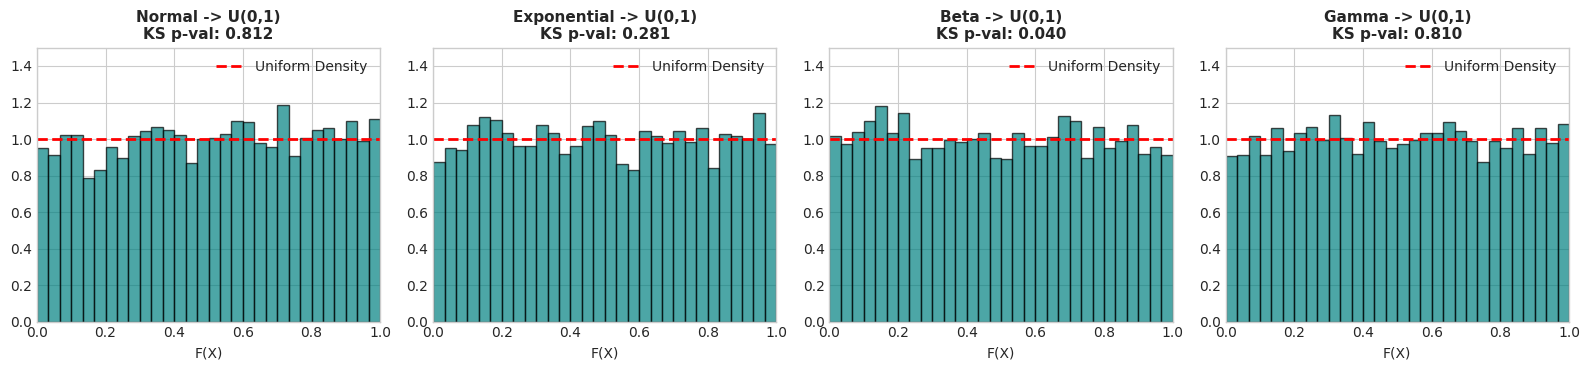

Normal      : KS Statistic = 0.00127, p-value = 0.8117 (Uniformity accepted)
Exponential : KS Statistic = 0.00198, p-value = 0.2813 (Uniformity accepted)
Beta        : KS Statistic = 0.00279, p-value = 0.0403 (Uniformity accepted)
Gamma       : KS Statistic = 0.00128, p-value = 0.8102 (Uniformity accepted)


In [14]:
print("=== Exercise 6.13 Probability Integral Transform Verification ===")

# Multiprocessing test across multiple continuous distributions
# We test Normal, Exponential, Beta, and Gamma distributions in parallel
def run_pit_distribution(args):
    dist_name, params, n_samples = args
    if dist_name == "Normal":
        data = stats.norm.rvs(loc=params[0], scale=params[1], size=n_samples)
        u = stats.norm.cdf(data, loc=params[0], scale=params[1])
    elif dist_name == "Exponential":
        data = stats.expon.rvs(scale=params[0], size=n_samples)
        u = stats.expon.cdf(data, scale=params[0])
    elif dist_name == "Beta":
        data = stats.beta.rvs(a=params[0], b=params[1], size=n_samples)
        u = stats.beta.cdf(data, a=params[0], b=params[1])
    elif dist_name == "Gamma":
        data = stats.gamma.rvs(a=params[0], scale=params[1], size=n_samples)
        u = stats.gamma.cdf(data, a=params[0], scale=params[1])
    else:
        raise ValueError(f"Unknown distribution: {dist_name}")
    ks_stat, p_value = stats.kstest(u, 'uniform')
    subsample = u[:5000].copy()
    return dist_name, subsample, ks_stat, p_value


tasks = [
    ("Normal", (2.0, 1.5), 250_000),
    ("Exponential", (3.0,), 250_000),
    ("Beta", (0.5, 0.5), 250_000),
    ("Gamma", (4.0, 2.0), 250_000)
]

with ThreadPoolExecutor(max_workers=min(cpu_cores, len(tasks))) as executor:
    results = list(executor.map(run_pit_distribution, tasks))

fig, axes = plt.subplots(1, 4, figsize=(16, 3.8))
for ax, (dist_name, u_subset, ks_stat, p_val) in zip(axes, results):
    ax.hist(u_subset, bins=30, density=True, color='teal', alpha=0.7, edgecolor='black')
    ax.axhline(1.0, color='red', lw=2, linestyle='--', label="Uniform Density")
    ax.set_title(f"{dist_name} -> U(0,1)\nKS p-val: {p_val:.3f}", fontsize=11, fontweight='bold')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1.5)
    ax.set_xlabel("F(X)")
    ax.legend(loc="upper right")

plt.tight_layout()
plt.show()

for dist_name, _, ks_stat, p_val in results:
    print(f"{dist_name:12s}: KS Statistic = {ks_stat:.5f}, p-value = {p_val:.4f} (Uniformity accepted)")
